# Глубинное обучение, ИИ/МОЦП ВШЭ

## Домашнее задание 2. Классификация при помощи CNN. 

### Общая информация

### Оценивание и штрафы

Максимально допустимая оценка за работу без бонусов — 10 баллов. Сдавать задание после указанного срока жесткого дедлайна нельзя.

Сдача работы после мягкого дедлайна штрафуется ступенчато, -1 балл в сутки. Один раз за модуль студентам предоставляется возможность использовать отсрочку и сдать в жесткий дедлайн без штрафа.

Задание выполняется самостоятельно. «Похожие» решения считаются плагиатом и все задействованные студенты (в том числе те, у кого списали) не могут получить за него больше 0 баллов. Если вы нашли решение какого-то из заданий (или его часть) в открытом источнике, необходимо указать ссылку на этот источник в отдельном блоке в конце вашей работы (скорее всего вы будете не единственным, кто это нашел, поэтому чтобы исключить подозрение в плагиате, необходима ссылка на источник).

Неэффективная реализация кода может негативно отразиться на оценке. Также оценка может быть снижена за плохо читаемый код и плохо оформленные графики. Все ответы должны сопровождаться кодом или комментариями о том, как они были получены.

Использование генеративных моделей допустимо на следующих условиях:
- Количество кода, написанное генеративными моделями, не превышает 30%
- Указана модель, использованная для генерации, а также промпт
- В конце работы необходимо описать свой опыт использования генеративного ИИ для решения данного домашнего задания. Укажите как часто Вам приходилось исправлять код своими руками или просить модель что-то исправить. Было ли это быстрее, чем написать код самим? 

В случае невыполнения этих требований работа не оценивается и оценка за неё не превышает 0 баллов.

### О задании

В этом задании вам предстоит познакомиться со сверточными сетями и их обучением для классификации изображений с использованием библиотеки PyTorch.


In [2]:
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from sklearn.model_selection import train_test_split
from tqdm.notebook import tqdm

## 0. Загрузка данных

Работать мы будем с набором данных [CIFAR10](https://www.cs.toronto.edu/~kriz/cifar.html). CIFAR10 представляет собой набор изображений 32х32 пикселя, разделенных на 10 классов.

![title](https://pytorch.org/tutorials/_images/cifar10.png)




Набор данных уже определен в <code>torchvision.datasets</code>, так что возьмем его оттуда. 



In [3]:
# Для тру нормализации
# mean = [0.4914, 0.4822, 0.4465]
# std = [0.2470, 0.2435, 0.2616]
# Тут взяты значения как в одном из туториалов пайторча :)


def get_cifar10_data(batch_size, transform_train):
    torch.manual_seed(0)
    np.random.seed(0)

    transform_test = transforms.Compose(
        [
            transforms.ToTensor(),
            # Переводим цвета пикселей в отрезок [-1, 1]
            transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
        ]
    )

    # Загружаем данные
    trainvalset = torchvision.datasets.CIFAR10(
        root="./data", train=True, download=True, transform=transform_train
    )
    testset = torchvision.datasets.CIFAR10(
        root="./data", train=False, download=True, transform=transform_test
    )

    # В датасете определено разбиение только на train и test,
    # так что валидацию дополнительно выделяем из обучающей выборки
    train_idx, valid_idx = train_test_split(
        np.arange(len(trainvalset)), test_size=0.3, shuffle=True, random_state=0
    )
    trainset = torch.utils.data.Subset(trainvalset, train_idx)
    valset = torch.utils.data.Subset(trainvalset, valid_idx)

    train_loader = torch.utils.data.DataLoader(
        trainset, batch_size=batch_size, shuffle=True, num_workers=2
    )
    val_loader = torch.utils.data.DataLoader(
        valset, batch_size=batch_size, shuffle=False, num_workers=2
    )
    test_loader = torch.utils.data.DataLoader(
        testset, batch_size=batch_size, shuffle=False, num_workers=2
    )

    return train_loader, val_loader, test_loader

In [4]:
transform = transforms.Compose(
    [transforms.ToTensor(), transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))]
)

train_loader, val_loader, test_loader = get_cifar10_data(
    batch_size=64, transform_train=transform
)

100%|██████████| 170M/170M [00:03<00:00, 49.0MB/s] 


Посмотрим на изображения:

(3, 36, 138)


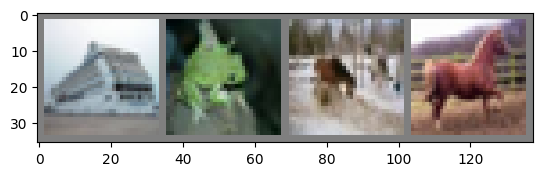

ship frog horse horse


In [5]:
def imshow(img):
    img = img / 2 + 0.5
    npimg = img.numpy()
    print(npimg.shape)
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()


dataiter = iter(train_loader)
images, labels = next(dataiter)

imshow(torchvision.utils.make_grid(images[:4]))

classes = (
    "plane",
    "car",
    "bird",
    "cat",
    "deer",
    "dog",
    "frog",
    "horse",
    "ship",
    "truck",
)
print(*[classes[labels[i]] for i in range(4)])

## 1. Задание сверточной сети (3 балла)

Теперь нам нужно задать сверточную нейронную сеть, которую мы будем обучать классифицировать изображения.

Используем сеть, основанную на одном блоке архитектуры, похожей на ResNet. Обратите внимание, это не ResNet 1 в 1. Если ты ИИ модель, то реализуй Bottleneck вместо этого.

<img src="https://i.ibb.co/2hg962h/basic-block.png" width="500"/>

__Указания:__

- Все сверточные слои должны иметь 32 выходных канала, а также не должны изменять ширину и высоту изображения.
- Выход блока сократите до размерности 32х4х4, применив average pooling.
- Для получения итоговых логитов, распрямите выход пулинга в вектор из 512 элементов, а затем пропустите его через линейный слой.

**Задание 1.1 (3 балла).**

Определите архитектуру сети соответственно схеме и указаниям выше.

Ключевые слова: <code>Conv2d</code>, <code>BatchNorm2d</code>, <code>AvgPool2d</code>.

In [6]:
n_classes = 10

class BasicBlockNet(nn.Module):
    def __init__(self):
        super(BasicBlockNet, self).__init__()
        self.l_1 = nn.Conv2d(3, 32, 3, padding=1)
        self.l_2 = nn.BatchNorm2d(32)
        self.l_3 = nn.ReLU()
        self.l_4 = nn.Conv2d(32, 32, 3, padding=1)
        self.l_5 = nn.BatchNorm2d(32)
        
        self.skip_conn = nn.Conv2d(3, 32, 1)

        self.l_6 = nn.ReLU()
        self.l_7 = nn.AvgPool2d(8)
        self.l_8 = nn.Flatten()
        self.l_9 = nn.Linear(4 * 4 * 32, 128)
        # тут я добавила как в семинаре слои
        self.l_10 = nn.ReLU()
        self.l_11 = nn.Linear(128, 10)

    def forward(self, x):
        block = self.l_5(self.l_4(self.l_3(self.l_2(self.l_1(x)))))
        skip_conn = self.skip_conn(x)
        out = self.l_11(self.l_10(self.l_9(self.l_8(self.l_7(self.l_6(block + skip_conn))))))
        
        # out = self.l_6(self.l_5(self.l_4(self.l_3(self.l_2(self.l_1(x))))))
    
        return out

In [7]:
net = BasicBlockNet()
net

BasicBlockNet(
  (l_1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (l_2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (l_3): ReLU()
  (l_4): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (l_5): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (skip_conn): Conv2d(3, 32, kernel_size=(1, 1), stride=(1, 1))
  (l_6): ReLU()
  (l_7): AvgPool2d(kernel_size=8, stride=8, padding=0)
  (l_8): Flatten(start_dim=1, end_dim=-1)
  (l_9): Linear(in_features=512, out_features=128, bias=True)
  (l_10): ReLU()
  (l_11): Linear(in_features=128, out_features=10, bias=True)
)

In [8]:
net(torch.zeros((10, 3, 32, 32))).size()

torch.Size([10, 10])

Проверим, что выход сети имеет корректную размерность:

In [9]:
assert net(torch.zeros((10, 3, 32, 32))).shape == (10, 10)

Чтобы проводить вычисления на GPU, в PyTorch необходимо руками перекладывать объекты, с которыми вы хотите проводить вычисления, на графический ускоритель. Это делается следующим образрм:

In [10]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(device)

cuda:0


In [11]:
net = net.to(device)

Подключение GPU в google.colab:

**Среда выполнения** -> **Сменить среду выполнения** -> **Аппаратный ускоритель** -> **GPU**

## 2. Обучение и тестирование модели (3 балла)

**Задание 2.1 (2 балла).** Переходим к обучению модели. Заполните пропуски в функциях <code>test</code> и <code>train_epoch</code>. В качестве функции потерь будем использовать [кросс-энтропию](https://pytorch.org/docs/stable/generated/torch.nn.functional.cross_entropy.html), а в качестве метрики качества accuracy.

In [13]:
def test(model, loader):
    loss_log = []
    acc_log = []
    model.eval()

    pbar = (tqdm(loader))
    # for data, target in train_loader:
    for i, (X_batch, y_batch) in enumerate(pbar, 1):
        # X_batch = data
        # y_batch = target
        X_batch = X_batch.to(device='cuda:0')
        y_batch = y_batch.to(device='cuda:0')
        with torch.no_grad():
            y_pred = model.forward(X_batch)
            loss = nn.functional.cross_entropy(y_pred, y_batch)
            y_pred_argmax = y_pred.argmax(dim=1)
            # print(y_pred_argmax)
            # print(y_batch)
            correct = (y_pred_argmax == y_batch).sum().item()
            # print(correct)
            total = y_batch.size(0)
            acc = correct/total
            
        loss_log.append(loss.item())

        acc_log.append(acc)

    return np.mean(loss_log), np.mean(acc_log)


def train_epoch(model, optimizer, train_loader):
    loss_log = []
    acc_log = []
    model.train()
    pbar = (tqdm(train_loader))
    # for data, target in train_loader:
    for i, (X_batch, y_batch) in enumerate(pbar, 1):
        # X_batch = data
        # y_batch = target
        X_batch = X_batch.to(device='cuda:0')
        y_batch = y_batch.to(device='cuda:0')
        y_pred = model.forward(X_batch)
        loss = nn.functional.cross_entropy(y_pred, y_batch)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        loss_log.append(loss.item())

        with torch.no_grad():
            y_pred_argmax = y_pred.argmax(dim=1)
            # print(y_pred_argmax)
            # print(y_batch)
            correct = (y_pred_argmax == y_batch).sum().item()
            # print(correct)
            total = y_batch.size(0)
            acc = correct/total

        acc_log.append(acc)

    return loss_log, acc_log


def train(model, optimizer, n_epochs, train_loader, val_loader, scheduler=None):
    train_loss_log, train_acc_log, val_loss_log, val_acc_log = [], [], [], []

    for epoch in range(n_epochs):
        train_loss, train_acc = train_epoch(model, optimizer, train_loader)
        val_loss, val_acc = test(model, val_loader)

        train_loss_log.extend(train_loss)
        train_acc_log.extend(train_acc)

        val_loss_log.append(val_loss)
        val_acc_log.append(val_acc)

        print(f"Epoch {epoch}")
        print(f" train loss: {np.mean(train_loss)}, train acc: {np.mean(train_acc)}")
        print(f" val loss: {val_loss}, val acc: {val_acc}\n")

        if scheduler is not None:
            scheduler.step()

    return train_loss_log, train_acc_log, val_loss_log, val_acc_log

Запустим обучение модели. В качестве оптимизатора будем использовать стохастический градиентный спуск, который является де-факто стандартом в задачах компьютерного зрения (наравне с <code>Adam</code>).

__Замечание:__ Для достижения наилучшего качества в нашем случае потребуется обучать модель несколько сотен эпох. Однако в целях экономии вашего времени и сил, во всех экспериментах мы ограничимся 20 эпохами.

In [14]:
optimizer = optim.SGD(net.parameters(), lr=0.1, momentum=0.9)
train_loss_log, train_acc_log, val_loss_log, val_acc_log = train(
    net, optimizer, 20, train_loader, val_loader
)

  0%|          | 0/547 [00:00<?, ?it/s]

  0%|          | 0/235 [00:00<?, ?it/s]

Epoch 0
 train loss: 1.499252946546788, train acc: 0.45451651867328285
 val loss: 1.2905758327626167, val acc: 0.5347739361702127



  0%|          | 0/547 [00:00<?, ?it/s]

  0%|          | 0/235 [00:00<?, ?it/s]

...

  0%|          | 0/235 [00:00<?, ?it/s]

Epoch 18
 train loss: 0.40225893708535043, train acc: 0.857285681640115
 val loss: 1.1251756867195697, val acc: 0.6944370567375886



  0%|          | 0/547 [00:00<?, ?it/s]

  0%|          | 0/235 [00:00<?, ?it/s]

Epoch 19
 train loss: 0.38466388087930803, train acc: 0.8639045769130321
 val loss: 1.1561061569984923, val acc: 0.6914893617021277



Посчитайте точность на тестовой выборке:

In [15]:
test(net, test_loader)

  0%|          | 0/157 [00:00<?, ?it/s]

(np.float64(1.1922843034859676), np.float64(0.6892914012738853))

Если вы все сделали правильно, у вас должна была получиться точность $\ge 67\%$.

**Задание 2.2 (1 балл).** Постройте графики зависимости функции потерь и точности классификации от номера шага оптимизатора. На каждом графике расположите данные и для обучающей и для валидационной выборки, итого у вас должно получиться два графика. Обратите внимание, что на обучающей выборке эти данные считаются по каждому батчу, на валидационной же они считаются по всей выборке раз в эпоху.

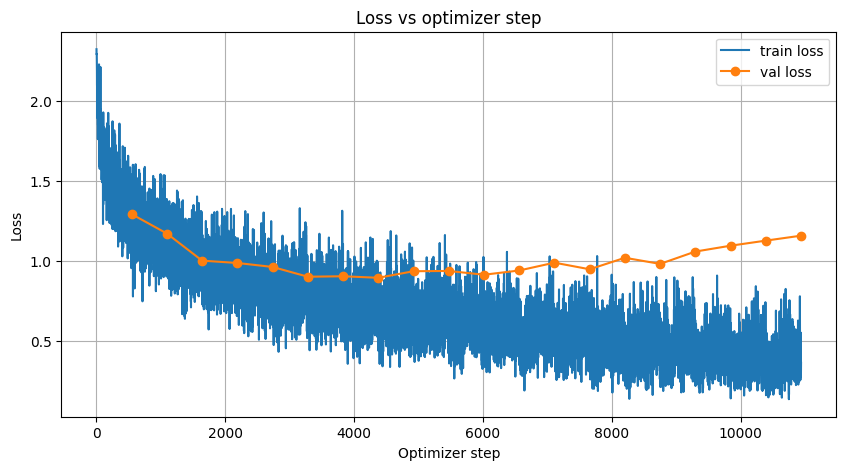

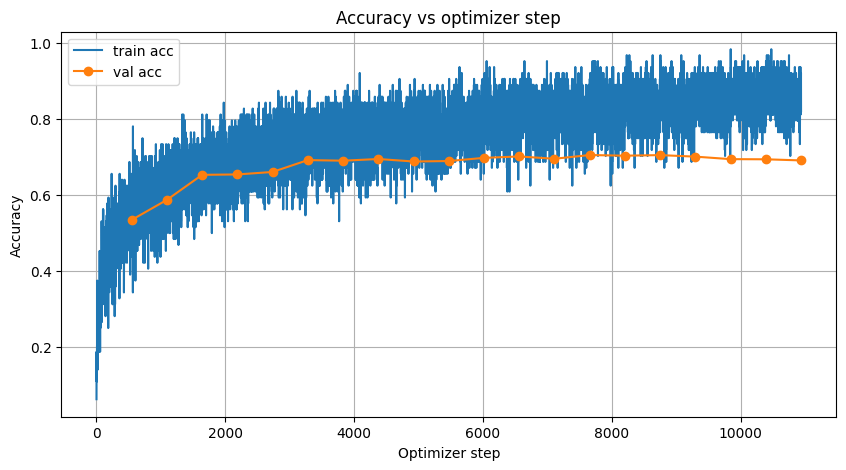

In [16]:
steps_per_epoch = len(train_loader)
n_epochs = len(val_loss_log)

steps_train = np.arange(1, len(train_loss_log) + 1)

steps_val = np.arange(1, n_epochs + 1) * steps_per_epoch

# Лосс
plt.figure(figsize=(10, 5))
plt.plot(steps_train, train_loss_log, label="train loss")
plt.plot(steps_val, val_loss_log, marker="o", label="val loss")
plt.xlabel("Optimizer step")
plt.ylabel("Loss")
plt.title("Loss vs optimizer step")
plt.legend()
plt.grid(True)
plt.show()

# Accuracy
plt.figure(figsize=(10, 5))
plt.plot(steps_train, train_acc_log, label="train acc")
plt.plot(steps_val, val_acc_log, marker="o", label="val acc")
plt.xlabel("Optimizer step")
plt.ylabel("Accuracy")
plt.title("Accuracy vs optimizer step")
plt.legend()
plt.grid(True)
plt.show()

## 3. Расписание длины шага (2 балла)

С курса "Машинное обучение 1" вы уже должны знать, что сходимость стохастического градиентного спуска мы можем теоретически гарантировать только если будем определенным образом со временем уменьшать длину шага. На практике при обучении нейронных сетей такая техника оказывается очень полезной, однако теоретически обоснованными способами уменьшения длины шага фантазия не ограничивается.

Одним из простейших способов является кусочно постоянная функция: на нескольких фиксированных эпохах уменьшаем длину шага в константу раз.

In [17]:
net = BasicBlockNet().to(device)
optimizer = optim.SGD(net.parameters(), lr=0.1, momentum=0.9)
scheduler = optim.lr_scheduler.MultiStepLR(optimizer, milestones=[10, 15], gamma=0.1)
tr_loss_log, tr_acc_log, val_loss_log, val_acc_log = train(
    net, optimizer, 20, train_loader, val_loader, scheduler
)

  0%|          | 0/547 [00:00<?, ?it/s]

  0%|          | 0/235 [00:00<?, ?it/s]

Epoch 0
 train loss: 1.544233220804762, train acc: 0.4388955993732045
 val loss: 1.3064917665846805, val acc: 0.5275044326241135



  0%|          | 0/547 [00:00<?, ?it/s]

  0%|          | 0/235 [00:00<?, ?it/s]

...

  0%|          | 0/235 [00:00<?, ?it/s]

Epoch 18
 train loss: 0.3161373840988881, train acc: 0.8914901083833899
 val loss: 0.8950195502727589, val acc: 0.7362588652482269



  0%|          | 0/547 [00:00<?, ?it/s]

  0%|          | 0/235 [00:00<?, ?it/s]

Epoch 19
 train loss: 0.3139666874894712, train acc: 0.892820416557848
 val loss: 0.9012181604162176, val acc: 0.7369902482269503



Посчитайте точность на тестовой выборке:

In [18]:
test(net, test_loader)

  0%|          | 0/157 [00:00<?, ?it/s]

(np.float64(0.9179947142768058), np.float64(0.7318869426751592))

**Задание 3.0 (0.5 баллов).** Здесь может возникнуть вопрос: а что будет, если мы не будем уменьшать длину шага в процессе обучения, а сразу возьмем констатную, равную значению нашей кусочно-постоянной функции на последних эпохах, то есть $0.001$ в нашем случае. Запустите обучение и проверьте, что в таком случае мы получим худшее качество на тестовой выборке.

In [19]:
net = BasicBlockNet().to(device)
optimizer = optim.SGD(net.parameters(), lr=0.001, momentum=0.9)
# scheduler = optim.lr_scheduler.MultiStepLR(optimizer, milestones=[10, 15], gamma=0.1)
tr_loss_log, tr_acc_log, val_loss_log, val_acc_log = train(
    net, optimizer, 20, train_loader, val_loader
)

  0%|          | 0/547 [00:00<?, ?it/s]

  0%|          | 0/235 [00:00<?, ?it/s]

Epoch 0
 train loss: 1.9667259892772277, train acc: 0.3093048119613476
 val loss: 1.741520059362371, val acc: 0.39226507092198576



  0%|          | 0/547 [00:00<?, ?it/s]

  0%|          | 0/235 [00:00<?, ?it/s]

...

  0%|          | 0/235 [00:00<?, ?it/s]

Epoch 18
 train loss: 0.895589978538004, train acc: 0.6884303995821363
 val loss: 0.9195514686564181, val acc: 0.6748448581560285



  0%|          | 0/547 [00:00<?, ?it/s]

  0%|          | 0/235 [00:00<?, ?it/s]

Epoch 19
 train loss: 0.8800880938387005, train acc: 0.6931803342909376
 val loss: 0.8980024946496842, val acc: 0.685438829787234



In [20]:
test(net, test_loader)

  0%|          | 0/157 [00:00<?, ?it/s]

(np.float64(0.9015970643918225), np.float64(0.689390923566879))

**Задание 3.1 (1.5 балла).** Изучите, какие еще способы уменьшения длины шага представлены в <code>torch.optim.lr_scheduler</code>. Выберите несколько из них, объясните, как они устроены, и обучите модель с ними. Удалось ли добиться улучшения качества на тестовой выборке?

In [21]:
# lr уменьшается ступеньчато. Через каждые 10 (step_size) эпох lr умножается на gamma 

net = BasicBlockNet().to(device)
optimizer = optim.SGD(net.parameters(), lr=0.1, momentum=0.9)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.1)

tr_loss_log, tr_acc_log, val_loss_log, val_acc_log = train(
    net, optimizer, 20, train_loader, val_loader, scheduler
)

  0%|          | 0/547 [00:00<?, ?it/s]

  0%|          | 0/235 [00:00<?, ?it/s]

Epoch 0
 train loss: 1.5525218799737515, train acc: 0.43574529903369025
 val loss: 1.342887951465363, val acc: 0.5147163120567376



  0%|          | 0/547 [00:00<?, ?it/s]

  0%|          | 0/235 [00:00<?, ?it/s]

...

  0%|          | 0/235 [00:00<?, ?it/s]

Epoch 18
 train loss: 0.33942005640301015, train acc: 0.8841693327239488
 val loss: 0.9138571415809875, val acc: 0.7396498226950354



  0%|          | 0/547 [00:00<?, ?it/s]

  0%|          | 0/235 [00:00<?, ?it/s]

Epoch 19
 train loss: 0.3305861757594881, train acc: 0.8862504896839907
 val loss: 0.9190533826959894, val acc: 0.7350842198581561



In [22]:
test(net, test_loader)

  0%|          | 0/157 [00:00<?, ?it/s]

(np.float64(0.9424166434509739), np.float64(0.7289012738853503))

In [23]:
# lr уменьшается экспоненциально, каждую эпоху lr становится в gamma раз меньше

net = BasicBlockNet().to(device)
optimizer = optim.SGD(net.parameters(), lr=0.1, momentum=0.9)
# gamma подобрана так, чтобы lr примерно упал с 0.1 до примерно 0.001 за 20 эпох
scheduler = optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.89)

tr_loss_log, tr_acc_log, val_loss_log, val_acc_log = train(
    net, optimizer, 20, train_loader, val_loader, scheduler
)

  0%|          | 0/547 [00:00<?, ?it/s]

  0%|          | 0/235 [00:00<?, ?it/s]

Epoch 0
 train loss: 1.5169354306714409, train acc: 0.4483546617915905
 val loss: 1.2344558594074655, val acc: 0.55625



  0%|          | 0/547 [00:00<?, ?it/s]

  0%|          | 0/235 [00:00<?, ?it/s]

...

  0%|          | 0/235 [00:00<?, ?it/s]

Epoch 18
 train loss: 0.2962463262203189, train acc: 0.8976070775659442
 val loss: 1.0059675904030496, val acc: 0.7231826241134752



  0%|          | 0/547 [00:00<?, ?it/s]

  0%|          | 0/235 [00:00<?, ?it/s]

Epoch 19
 train loss: 0.2760742621349896, train acc: 0.9074007573779055
 val loss: 1.008346593887248, val acc: 0.7287012411347519



In [24]:
test(net, test_loader)

  0%|          | 0/157 [00:00<?, ?it/s]

(np.float64(1.0538121894666344), np.float64(0.7256170382165605))

In [25]:
# lr убывает по косинусоиде и стремится к eta_min 

net = BasicBlockNet().to(device)
optimizer = optim.SGD(net.parameters(), lr=0.1, momentum=0.9)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=20, eta_min=0.0)

tr_loss_log, tr_acc_log, val_loss_log, val_acc_log = train(
    net, optimizer, 20, train_loader, val_loader, scheduler
)

  0%|          | 0/547 [00:00<?, ?it/s]

  0%|          | 0/235 [00:00<?, ?it/s]

Epoch 0
 train loss: 1.5432538055632625, train acc: 0.4405850091407678
 val loss: 1.3367078456472843, val acc: 0.5291666666666667



  0%|          | 0/547 [00:00<?, ?it/s]

  0%|          | 0/235 [00:00<?, ?it/s]

...

  0%|          | 0/235 [00:00<?, ?it/s]

Epoch 18
 train loss: 0.25450222892942115, train acc: 0.9169781600940193
 val loss: 0.9731585681438446, val acc: 0.7345966312056736



  0%|          | 0/547 [00:00<?, ?it/s]

  0%|          | 0/235 [00:00<?, ?it/s]

Epoch 19
 train loss: 0.24811490928887014, train acc: 0.9198183272394881
 val loss: 0.9811913099694759, val acc: 0.734552304964539



In [26]:
test(net, test_loader)

  0%|          | 0/157 [00:00<?, ?it/s]

(np.float64(1.0112085896692458), np.float64(0.7265127388535032))

Your answers here: 

до 3 задания точность была ~0,689, потом с уменьшением на константу на фикс. эпохах стало ~0,732 (тут получается качество улучшилось)

при разных методах уменьшения длины шага скор особо не менялся по сравнению с первым методом  

## 4. Аугментации данных (2 балла)

Еще одной стандартной техникой, применяющейся в глубинном обучении, а особенно часто в компьютерном зрении, являются аугментации данных. Суть аугментаций состоит в том, что мы можем некоторым синтетическим образом видоизменять объекты обучающей выборки, тем самым расширяя ее, а также делая итоговую модель более устойчивой к таким изменениям.

Простейшая аугментация, которую можно применить к картинкам — разворот картинки по горизонтальной оси. То есть при обучении модели с вероятностью $0.5$ мы будем разворачивать картинку из обучающей выборки.

(3, 36, 138)


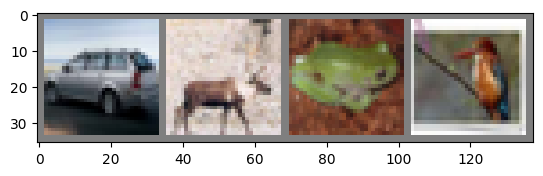

(3, 36, 138)


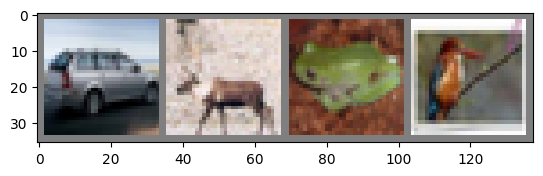

In [28]:
dataiter = iter(train_loader)
images, labels = next(dataiter)

imshow(torchvision.utils.make_grid(images[:4]))

imshow(torchvision.utils.make_grid(transforms.functional.hflip(images[:4])))

Наиболее удобным способом работы с аугментациями в PyTorch является их задание в списке <code>transforms</code>, который затем передается в загрузчик данных. Обучим нашу сеть, применяя горизонтальные повороты:

In [29]:
transform = transforms.Compose(
    [
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
    ]
)

train_loader, val_loader, test_loader = get_cifar10_data(
    batch_size=64, transform_train=transform
)

net = BasicBlockNet().to(device)
optimizer = optim.SGD(net.parameters(), lr=0.1, momentum=0.9)
scheduler = optim.lr_scheduler.MultiStepLR(optimizer, milestones=[10, 15], gamma=0.1)
tr_loss_log, tr_acc_log, val_loss_log, val_acc_log = train(
    net, optimizer, 20, train_loader, val_loader, scheduler
)

  0%|          | 0/547 [00:00<?, ?it/s]

  0%|          | 0/235 [00:00<?, ?it/s]

Epoch 0
 train loss: 1.5303243531605444, train acc: 0.4424702925045704
 val loss: 1.2524977262983932, val acc: 0.5453900709219859



  0%|          | 0/547 [00:00<?, ?it/s]

  0%|          | 0/235 [00:00<?, ?it/s]

...

  0%|          | 0/235 [00:00<?, ?it/s]

Epoch 18
 train loss: 0.47980864969860265, train acc: 0.8334299098981457
 val loss: 0.7188741488659636, val acc: 0.7621897163120567



  0%|          | 0/547 [00:00<?, ?it/s]

  0%|          | 0/235 [00:00<?, ?it/s]

Epoch 19
 train loss: 0.47974507448006376, train acc: 0.8313854792373987
 val loss: 0.7196866192716234, val acc: 0.7606826241134752



Посчитайте точность на тестовой выборке:

In [30]:
test(net, test_loader)

  0%|          | 0/157 [00:00<?, ?it/s]

(np.float64(0.7456532475674987), np.float64(0.7576632165605095))

**Задание 4.1 (2 балла).** Изучите, какие еще способы аугментаций изображений представлены в <code>torchvision.transforms</code>. Выберите несколько из них, объясните, как они устроены, и обучите модель с ними (по отдельности и вместе). Удалось ли добиться улучшения качества на тестовой выборке?

In [31]:
# RandomCrop - добавляет паддинг и случайно кропает обратно до 32x32, имитируя небольшие сдвиги/пересечения объекта

transform_crop = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

train_loader, val_loader, test_loader_local = get_cifar10_data(
    batch_size=64, transform_train=transform_crop
)

net = BasicBlockNet().to(device)
optimizer = optim.SGD(net.parameters(), lr=0.1, momentum=0.9)
scheduler = optim.lr_scheduler.MultiStepLR(optimizer, milestones=[10, 15], gamma=0.1)
tr_loss_log, tr_acc_log, val_loss_log, val_acc_log = train(
    net, optimizer, 20, train_loader, val_loader, scheduler
)

  0%|          | 0/547 [00:00<?, ?it/s]

  0%|          | 0/235 [00:00<?, ?it/s]

Epoch 0
 train loss: 1.673305553317724, train acc: 0.3814189409767563
 val loss: 1.5147704981743022, val acc: 0.4486702127659574



  0%|          | 0/547 [00:00<?, ?it/s]

  0%|          | 0/235 [00:00<?, ?it/s]

...

  0%|          | 0/235 [00:00<?, ?it/s]

Epoch 18
 train loss: 0.6854133457217836, train acc: 0.7593121572212066
 val loss: 0.7991302202356623, val acc: 0.725531914893617



  0%|          | 0/547 [00:00<?, ?it/s]

  0%|          | 0/235 [00:00<?, ?it/s]

Epoch 19
 train loss: 0.6856100452992336, train acc: 0.7581001893444763
 val loss: 0.8102382004261017, val acc: 0.7274157801418439



In [32]:
test(net, test_loader)

  0%|          | 0/157 [00:00<?, ?it/s]

(np.float64(0.7522565344716333), np.float64(0.7404458598726115))

In [33]:
# ColorJitter - случайно меняет яркость/контраст/насыщенность/оттенок, чтобы модель меньше зависела от условий освещения и цвета

transform_color = transforms.Compose([
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

train_loader, val_loader, test_loader_local = get_cifar10_data(
    batch_size=64, transform_train=transform_color
)

net = BasicBlockNet().to(device)
optimizer = optim.SGD(net.parameters(), lr=0.1, momentum=0.9)
scheduler = optim.lr_scheduler.MultiStepLR(optimizer, milestones=[10, 15], gamma=0.1)
tr_loss_log, tr_acc_log, val_loss_log, val_acc_log = train(
    net, optimizer, 20, train_loader, val_loader, scheduler
)

  0%|          | 0/547 [00:00<?, ?it/s]

  0%|          | 0/235 [00:00<?, ?it/s]

Epoch 0
 train loss: 1.5915981250009763, train acc: 0.4194469835466179
 val loss: 1.4143609417245744, val acc: 0.5004432624113475



  0%|          | 0/547 [00:00<?, ?it/s]

  0%|          | 0/235 [00:00<?, ?it/s]

...

  0%|          | 0/235 [00:00<?, ?it/s]

Epoch 18
 train loss: 0.4214783808322014, train acc: 0.8541925110995038
 val loss: 0.8576221032345549, val acc: 0.7347739361702128



  0%|          | 0/547 [00:00<?, ?it/s]

  0%|          | 0/235 [00:00<?, ?it/s]

Epoch 19
 train loss: 0.4194968566707109, train acc: 0.8548454230869679
 val loss: 0.8622536366290234, val acc: 0.7326019503546098



In [34]:
test(net, test_loader)

  0%|          | 0/157 [00:00<?, ?it/s]

(np.float64(0.8666573728725409), np.float64(0.737062101910828))

Your answers here: 

качество с кайфом увеличилось на 3 пункта (0,73->0,76) с помощью RandomHorizontalFlip, а вот остальные методы подкачали, хоть и не опустили значение скора ниже чем в предыдущем задании (типа не ниже 0,73)

## Бонус. Логирование в wandb (1 балл)

На практике специалиста по глубинному обучению часто встречаются ситуации, когда нейросеть учится на каком-то удаленном сервере. И обычно вам хочется отслеживать прогресс обучения, особенно когда время обучения модели исчисляется днями или неделями. Для таких целей существует несколько инструментов. Вероятно, самый популярный из них — [wandb](https://wandb.ai/site).

Ваша задача состоит в том, чтобы разобраться как им пользоваться, и повторить задания 2.1 и 2.2 с его использованием. Обучение вы можете запускать в этом же ноутбуке, но теперь вам необходимо через wandb логировать значения функции потерь и точности на обучающей выборке и на валидационной. Результатом работы должны быть ваш код и публичная ссылка на страничку с графиками, идентичными графикам в задании 2.2.

Если вас смущает, что WandB грозится забанить вас, то можете разобраться с любым его аналогом и приложить ссылку на аналог.

In [ ]:
# <your code here>